In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/raw/financial_phrasebank.csv")
print(df.shape)
df.head()

(4846, 2)


,sentence,sentiment_label
0,"According to Gran , the company has no plans t...",neutral
1,Technopolis plans to develop in stages an area...,neutral
2,The international electronic industry company ...,negative
3,With the new production plant the company woul...,positive
4,According to the company 's updated strategy f...,positive


In [2]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate sentences:", df['sentence'].duplicated().sum())
print("Nulls:\n", df.isnull().sum())

Duplicate rows: 6
Duplicate sentences: 8
Nulls:
 sentence           0
sentiment_label    0
dtype: int64


In [3]:
# Find sentences that appear more than once
dupe_sentences = df[df['sentence'].duplicated(keep=False)].sort_values('sentence')
print(dupe_sentences)

                                               sentence sentiment_label
2395  Ahlstrom 's share is quoted on the NASDAQ OMX ...         neutral
2396  Ahlstrom 's share is quoted on the NASDAQ OMX ...         neutral
3093  Proha Plc ( Euronext :7327 ) announced today (...         neutral
3094  Proha Plc ( Euronext :7327 ) announced today (...         neutral
2566  SSH Communications Security Corporation is hea...         neutral
2567  SSH Communications Security Corporation is hea...         neutral
78    TELECOMWORLDWIRE-7 April 2006-TJ Group Plc sel...         neutral
79    TELECOMWORLDWIRE-7 April 2006-TJ Group Plc sel...        positive
788   The Group 's business is balanced by its broad...        positive
789   The Group 's business is balanced by its broad...         neutral
3205  The company serves customers in various indust...         neutral
3206  The company serves customers in various indust...         neutral
1098  The issuer is solely responsible for the conte...         

In [4]:
df = df.drop_duplicates(subset=['sentence', 'sentiment_label'])
df = df.drop_duplicates(subset=['sentence'], keep=False)

In [7]:
print(f"Final dataset size: {len(df)}")
print(df['sentiment_label'].value_counts())

df.to_csv("../data/raw/financial_phrasebank_clean.csv", index=False)

Final dataset size: 4836
sentiment_label
neutral     2871
positive    1361
negative     604
Name: count, dtype: int64


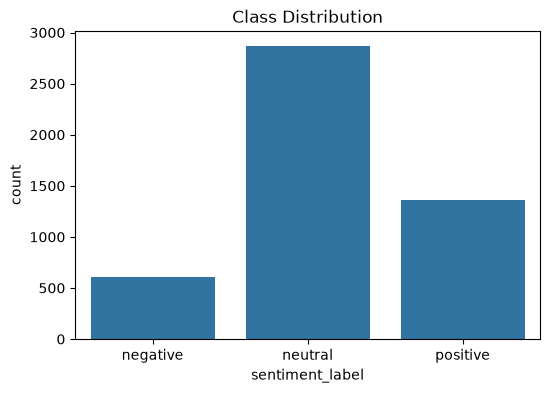

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='sentiment_label', order=['negative','neutral','positive'])
plt.title("Class Distribution") 
plt.show()

count    4836.000000
mean       23.086849
std         9.937150
min         2.000000
25%        16.000000
50%        21.000000
75%        29.000000
max        81.000000
Name: word_count, dtype: float64


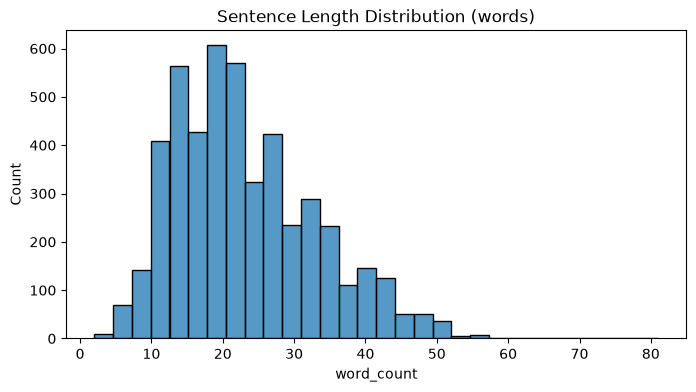

In [9]:
df['word_count'] = df['sentence'].apply(lambda x: len(x.split()))
print(df['word_count'].describe())

plt.figure(figsize=(8,4))
sns.histplot(df['word_count'], bins=30)
plt.title("Sentence Length Distribution (words)")
plt.show()

In [10]:
for label in ['negative', 'neutral', 'positive']:
    print(f"\n=== {label.upper()} samples ===")
    print(df[df['sentiment_label']==label]['sentence'].sample(3, random_state=42).to_string(index=False))


=== NEGATIVE samples ===
The company decided at the end of 2008 to tempo...
down to EUR5 .9 m H1 '09 3 August 2009 - Finnis...
The steelmaker said that the drop in profit was...

=== NEUTRAL samples ===
The total project duration is three years and i...
Upon establishment , the plan is directed to ap...
The company 's US subsidiary Vaisala Inc. acqui...

=== POSITIVE samples ===
Shares of Standard Chartered ( STAN ) rose 1.2 ...
It projected revenue of $ 2.2 billion to $ 2.3 ...
Technical indicators for the stock are bullish ...
